In [ ]:
# Student Performance Prediction Project
# Goal: Predict Pass/Fail based on study time and courses

In [1]:
pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:

import pandas as pd

df = pd.read_csv("student_marks.csv")
print(df.head())

   number_courses  time_study   Marks
0               3       4.508  19.202
1               4       0.096   7.734
2               4       3.133  13.811
3               6       7.909  53.018
4               8       7.811  55.299


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None
       number_courses  time_study       Marks
count      100.000000  100.000000  100.000000
mean         5.290000    4.077140   24.417690
std          1.799523    2.372914   14.326199
min          3.000000    0.096000    5.609000
25%          4.000000    2.058500   12.633000
50%          5.000000    4.022000   20.059500
75%          7.000000    6.179250   36.676250
max          8.000000    7.957000   55.299000


In [5]:
print(df.columns)

Index(['number_courses', 'time_study', 'Marks'], dtype='object')


In [7]:
df["result"] = df["Marks"].apply(lambda x: 1 if x > 40 else 0)
print(df.head())

   number_courses  time_study   Marks  result
0               3       4.508  19.202       0
1               4       0.096   7.734       0
2               4       3.133  13.811       0
3               6       7.909  53.018       1
4               8       7.811  55.299       1


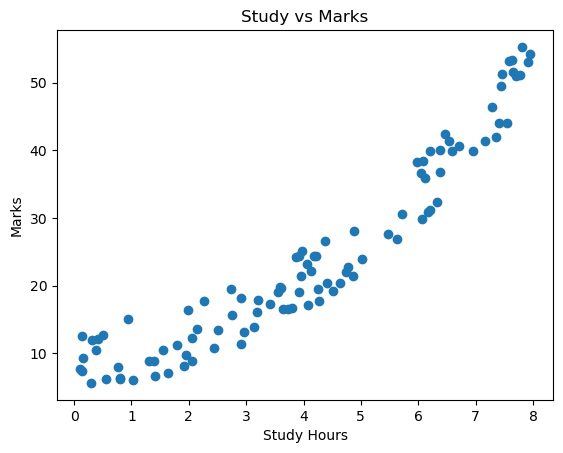

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df["time_study"], df["Marks"])
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study vs Marks")
plt.show()

In [9]:
X = df[["time_study", "number_courses"]]
y = df["result"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [12]:
predictions = model.predict(X_test)
print(predictions)

[0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0]


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [14]:
new_data = [[5, 3]]  # time_study=5, number_courses=3
result = model.predict(new_data)

print("Pass" if result[0] == 1 else "Fail")

Fail


C:\Users\IMRAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
